In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [2]:
traindata = torchvision.datasets.CIFAR10(
    root="/home/gantumur/Documents/DL/homework1/data",
    train=True,
    download=False,
    transform=transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
    )
)

/home/gantumur/miniconda3/envs/env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
testdata = torchvision.datasets.CIFAR10(
    root="/home/gantumur/Documents/DL/homework1/data",
    train=False,
    download=False,
    transform=transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
    )
)

In [4]:
train_size = int(len(traindata) * 0.8)
val_size = int(len(traindata) * 0.2)

train_set, val_set = torch.utils.data.random_split(
    traindata, [train_size, val_size])

In [5]:
trainloader = DataLoader(
    train_set,
    batch_size=32,
    shuffle=True
)


valloader = DataLoader(
    val_set,
    batch_size=32,
    shuffle=False
)

testloader = DataLoader(
    testdata,
    batch_size=32,
    shuffle=False
)

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class PaperCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(PaperCNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(
            in_channels=16, out_channels=128, kernel_size=3, stride=2, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(
            in_channels=128, out_channels=256, kernel_size=3, stride=2, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc = nn.Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        x = self.pool3(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)
        return x


if __name__ == "__main__":
    test_tensor = torch.randn(16, 3, 32, 32)
    model = PaperCNN()

    output = model(test_tensor)

    print(f"Input shape: {test_tensor.shape}")

Input shape: torch.Size([16, 3, 32, 32])


In [7]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PaperCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

epochs = 10

train_losses = []
val_losses = []
train_accs = [] 
val_accs = []   

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    train_correct = 0
    train_total = 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    avg_train_loss = running_loss / len(trainloader)
    train_acc = 100 * train_correct / train_total  

    train_losses.append(avg_train_loss)
    train_accs.append(train_acc) 

    model.eval()
    val_loss = 0.0
    val_correct = 0  
    val_total = 0   

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(valloader)
    val_acc = 100 * val_correct / val_total

    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)  

  
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch [1/10] Train Loss: 1.5018 | Train Acc: 45.85% | Val Loss: 1.3137 | Val Acc: 53.71%
Epoch [2/10] Train Loss: 1.1618 | Train Acc: 58.89% | Val Loss: 1.1113 | Val Acc: 61.03%
Epoch [3/10] Train Loss: 0.9920 | Train Acc: 65.02% | Val Loss: 1.0284 | Val Acc: 63.97%
Epoch [4/10] Train Loss: 0.8722 | Train Acc: 69.67% | Val Loss: 1.0308 | Val Acc: 64.29%
Epoch [5/10] Train Loss: 0.7723 | Train Acc: 73.06% | Val Loss: 1.0125 | Val Acc: 65.43%
Epoch [6/10] Train Loss: 0.6831 | Train Acc: 76.21% | Val Loss: 0.9138 | Val Acc: 68.68%
Epoch [7/10] Train Loss: 0.5987 | Train Acc: 79.14% | Val Loss: 0.8986 | Val Acc: 69.52%
Epoch [8/10] Train Loss: 0.5211 | Train Acc: 81.95% | Val Loss: 0.9174 | Val Acc: 69.46%
Epoch [9/10] Train Loss: 0.4496 | Train Acc: 84.50% | Val Loss: 1.0077 | Val Acc: 68.57%
Epoch [10/10] Train Loss: 0.3800 | Train Acc: 86.99% | Val Loss: 1.0436 | Val Acc: 68.48%


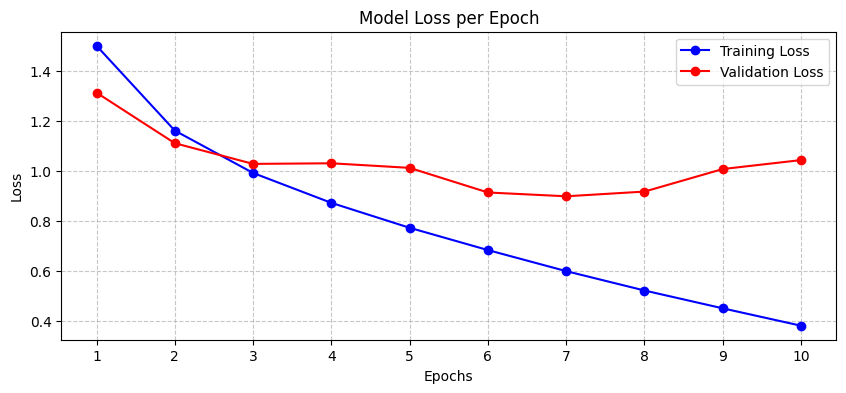

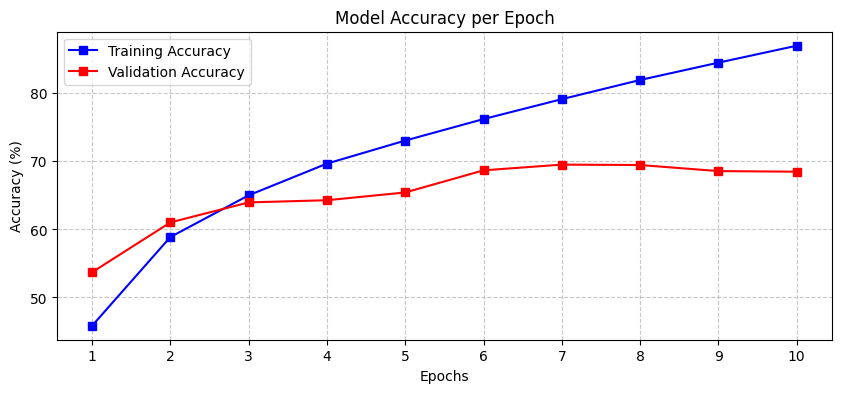

In [8]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(val_losses) + 1)


plt.figure(figsize=(10, 4)) 

plt.plot(epochs_range, train_losses, marker="o",
         label="Training Loss", color="blue")
plt.plot(epochs_range, val_losses, marker="o",
         label="Validation Loss", color="red")

plt.title("Model Loss per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


plt.figure(figsize=(10, 4))

plt.plot(epochs_range, train_accs, marker="s",
         label="Training Accuracy", color="blue")
plt.plot(epochs_range, val_accs, marker="s",
         label="Validation Accuracy", color="red")

plt.title("Model Accuracy per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [9]:
from torchinfo import summary


summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
PaperCNN                                 [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 30, 30]           448
├─MaxPool2d: 1-2                         [1, 16, 15, 15]           --
├─Conv2d: 1-3                            [1, 128, 8, 8]            18,560
├─MaxPool2d: 1-4                         [1, 128, 4, 4]            --
├─Conv2d: 1-5                            [1, 256, 2, 2]            295,168
├─MaxPool2d: 1-6                         [1, 256, 1, 1]            --
├─Linear: 1-7                            [1, 10]                   2,570
Total params: 316,746
Trainable params: 316,746
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.77
Input size (MB): 0.01
Forward/backward pass size (MB): 0.19
Params size (MB): 1.27
Estimated Total Size (MB): 1.47